<a href="https://colab.research.google.com/github/hemapriyaperugu-hub/ML_CEP_DIABETES/blob/main/ML_CEP_DIABETES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("All libraries imported successfully.")

All libraries imported successfully.


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving diabetes_data_upload[1].csv to diabetes_data_upload[1].csv


In [ ]:
df = pd.read_csv("diabetes_data_upload[1].csv")

print("Dataset loaded successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully.
Rows: 520
Columns: 17


,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive


In [ ]:
print("Column names:")
for column in df.columns:
    print(column)

Column names:
Age
Gender
Polyuria
Polydipsia
sudden weight loss
weakness
Polyphagia
Genital thrush
visual blurring
Itching
Irritability
delayed healing
partial paresis
muscle stiffness
Alopecia
Obesity
class


In [ ]:
print("Dataset Information:")
print()

df.info()

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Age                 520 non-null    int64 
 1   Gender              520 non-null    object
 2   Polyuria            520 non-null    object
 3   Polydipsia          520 non-null    object
 4   sudden weight loss  520 non-null    object
 5   weakness            520 non-null    object
 6   Polyphagia          520 non-null    object
 7   Genital thrush      520 non-null    object
 8   visual blurring     520 non-null    object
 9   Itching             520 non-null    object
 10  Irritability        520 non-null    object
 11  delayed healing     520 non-null    object
 12  partial paresis     520 non-null    object
 13  muscle stiffness    520 non-null    object
 14  Alopecia            520 non-null    object
 15  Obesity             520 non-null    object
 16  clas

In [ ]:
print("Missing values in each column:")
print(df.isnull().sum())

print()
print("Total missing values:", df.isnull().sum().sum())

Missing values in each column:
Age                   0
Gender                0
Polyuria              0
Polydipsia            0
sudden weight loss    0
weakness              0
Polyphagia            0
Genital thrush        0
visual blurring       0
Itching               0
Irritability          0
delayed healing       0
partial paresis       0
muscle stiffness      0
Alopecia              0
Obesity               0
class                 0
dtype: int64

Total missing values: 0


In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 269


In [ ]:
print("Statistical summary:")
df.describe()

Statistical summary:


,Age
count,520.000000
mean,48.028846
std,12.151466
min,16.000000
25%,39.000000
50%,47.500000
75%,57.000000
max,90.000000


In [ ]:
print("Diabetes class distribution:")
print(df["class"].value_counts())

Diabetes class distribution:
class
Positive    320
Negative    200
Name: count, dtype: int64


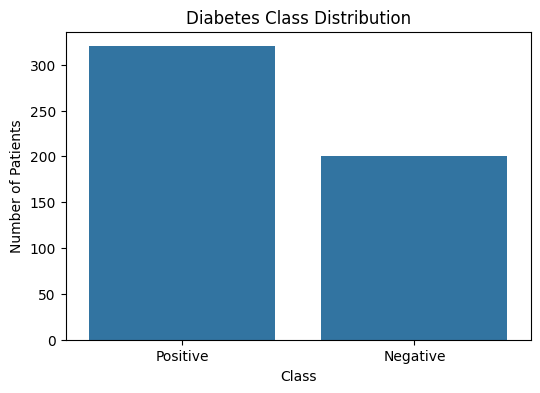

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(x="class", data=df)

plt.title("Diabetes Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Patients")

plt.show()

In [ ]:
data = df.copy()

print("Copy of dataset created.")
print(data.shape)

Copy of dataset created.
(520, 17)


In [ ]:
# Remove extra spaces from column names
data.columns = data.columns.str.strip()

# Remove extra spaces from categorical values
for column in data.columns:
    if data[column].dtype == "object":
        data[column] = data[column].str.strip()

print("Text values cleaned successfully.")

Text values cleaned successfully.


In [ ]:
binary_columns = [
    "Polyuria",
    "Polydipsia",
    "sudden weight loss",
    "weakness",
    "Polyphagia",
    "Genital thrush",
    "visual blurring",
    "Itching",
    "Irritability",
    "delayed healing",
    "partial paresis",
    "muscle stiffness",
    "Alopecia",
    "Obesity"
]

for column in binary_columns:
    data[column] = data[column].map({
        "Yes": 1,
        "No": 0
    })

print("Yes/No columns converted successfully.")

Yes/No columns converted successfully.


In [ ]:
data["Gender"] = data["Gender"].map({
    "Male": 1,
    "Female": 0
})

print("Gender converted successfully.")

Gender converted successfully.


In [ ]:
data["class"] = data["class"].map({
    "Positive": 1,
    "Negative": 0
})

print("Target class converted successfully.")

Target class converted successfully.


In [ ]:
print("Missing values after encoding:")
print(data.isnull().sum())

print()
print("Total missing values:", data.isnull().sum().sum())

Missing values after encoding:
Age                   0
Gender                0
Polyuria              0
Polydipsia            0
sudden weight loss    0
weakness              0
Polyphagia            0
Genital thrush        0
visual blurring       0
Itching               0
Irritability          0
delayed healing       0
partial paresis       0
muscle stiffness      0
Alopecia              0
Obesity               0
class                 0
dtype: int64

Total missing values: 0


In [ ]:
print("Processed dataset:")
display(data.head())

Processed dataset:


,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,1,0,1,0,1,0,0,0,1,0,1,0,1,1,1,1
1,58,1,0,0,0,1,0,0,1,0,0,0,1,0,1,0,1
2,41,1,1,0,0,1,1,0,0,1,0,1,0,1,1,0,1
3,45,1,0,0,1,1,1,1,0,1,0,1,0,0,0,0,1
4,60,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1


In [ ]:
X = data.drop("class", axis=1)
y = data["class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (520, 16)
Target shape: (520,)


In [ ]:
print("Missing values in X:", X.isnull().sum().sum())
print("Missing values in y:", y.isnull().sum())

Missing values in X: 0
Missing values in y: 0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (416, 16)
Testing data: (104, 16)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

knn_pred = knn.predict(X_test_scaled)

print("KNN Accuracy:",
      accuracy_score(y_test, knn_pred))

KNN Accuracy: 0.9326923076923077


In [ ]:
svm = SVC(
    kernel="rbf",
    random_state=42
)

svm.fit(X_train_scaled, y_train)

svm_pred = svm.predict(X_test_scaled)

print("SVM Accuracy:",
      accuracy_score(y_test, svm_pred))

SVM Accuracy: 0.9807692307692307


In [ ]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.9903846153846154


In [ ]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.9903846153846154


In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.9903846153846154


In [ ]:
# Naive Bayes
nb = GaussianNB()

nb.fit(X_train_scaled, y_train)

nb_pred = nb.predict(X_test_scaled)

print("Naive Bayes Accuracy:",
      accuracy_score(y_test, nb_pred))

Naive Bayes Accuracy: 0.9423076923076923


,Model,Accuracy,Accuracy (%)
0,KNN,0.932692,93.269231
1,Naive Bayes,0.942308,94.230769
2,SVM,0.980769,98.076923
3,Decision Tree,0.990385,99.038462
4,Random Forest,0.990385,99.038462


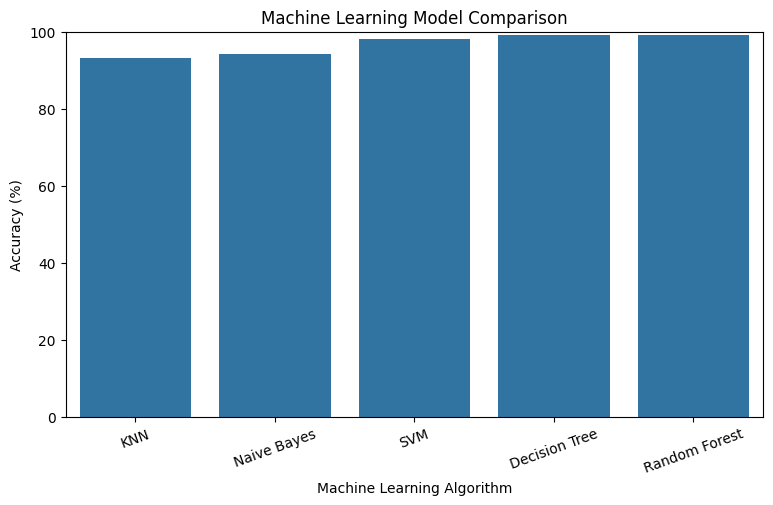

In [ ]:
results = pd.DataFrame({
    "Model": [
        "KNN",
        "Naive Bayes",
        "SVM",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

results["Accuracy (%)"] = results["Accuracy"] * 100

display(results)
plt.figure(figsize=(9, 5))

sns.barplot(
    x="Model",
    y="Accuracy (%)",
    data=results
)

plt.title("Machine Learning Model Comparison")
plt.xlabel("Machine Learning Algorithm")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

plt.xticks(rotation=20)

plt.show()

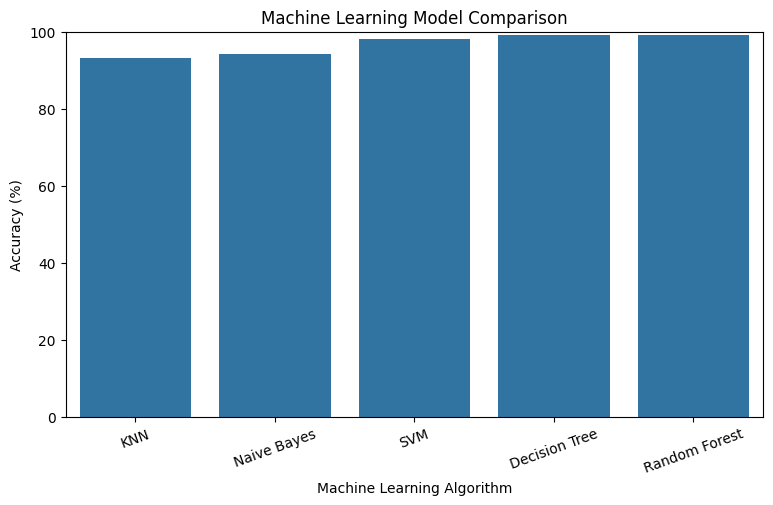

In [ ]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x="Model",
    y="Accuracy (%)",
    data=results
)

plt.title("Machine Learning Model Comparison")
plt.xlabel("Machine Learning Algorithm")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

plt.xticks(rotation=20)

plt.show()

In [ ]:
models = {
    "KNN": knn_pred,
    "Naive Bayes": nb_pred,
    "SVM": svm_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred
}

evaluation = []

for name, prediction in models.items():

    accuracy = accuracy_score(y_test, prediction)
    precision = precision_score(y_test, prediction)
    recall = recall_score(y_test, prediction)
    f1 = f1_score(y_test, prediction)

    evaluation.append([
        name,
        accuracy * 100,
        precision * 100,
        recall * 100,
        f1 * 100
    ])

evaluation_df = pd.DataFrame(
    evaluation,
    columns=[
        "Model",
        "Accuracy (%)",
        "Precision (%)",
        "Recall (%)",
        "F1 Score (%)"
    ]
)

display(evaluation_df)

,Model,Accuracy (%),Precision (%),Recall (%),F1 Score (%)
0,KNN,93.269231,98.305085,90.6250,94.308943
1,Naive Bayes,94.230769,96.774194,93.7500,95.238095
2,SVM,98.076923,98.437500,98.4375,98.437500
3,Decision Tree,99.038462,100.000000,98.4375,99.212598
4,Random Forest,99.038462,100.000000,98.4375,99.212598


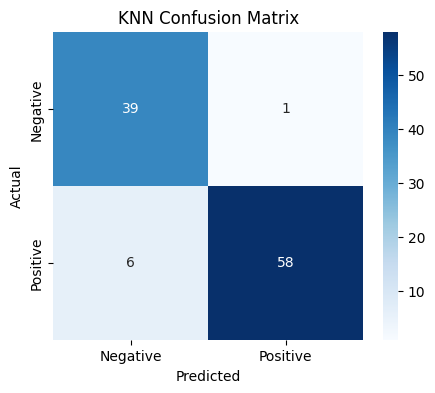

In [ ]:
cm = confusion_matrix(y_test, knn_pred)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")

plt.show()

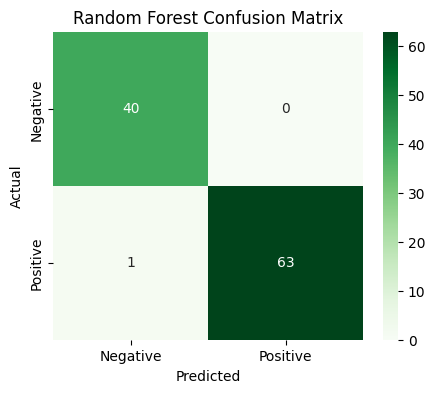

In [ ]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [ ]:
print("Random Forest Classification Report")
print()

print(
    classification_report(
        y_test,
        rf_pred,
        target_names=["Negative", "Positive"]
    )
)

Random Forest Classification Report

              precision    recall  f1-score   support

    Negative       0.98      1.00      0.99        40
    Positive       1.00      0.98      0.99        64

    accuracy                           0.99       104
   macro avg       0.99      0.99      0.99       104
weighted avg       0.99      0.99      0.99       104



In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

display(importance)

,Feature,Importance
2,Polyuria,0.204932
3,Polydipsia,0.180052
1,Gender,0.117120
0,Age,0.111317
4,sudden weight loss,0.056890
12,partial paresis,0.046034
14,Alopecia,0.043785
10,Irritability,0.036365
8,visual blurring,0.030040
11,delayed healing,0.029854


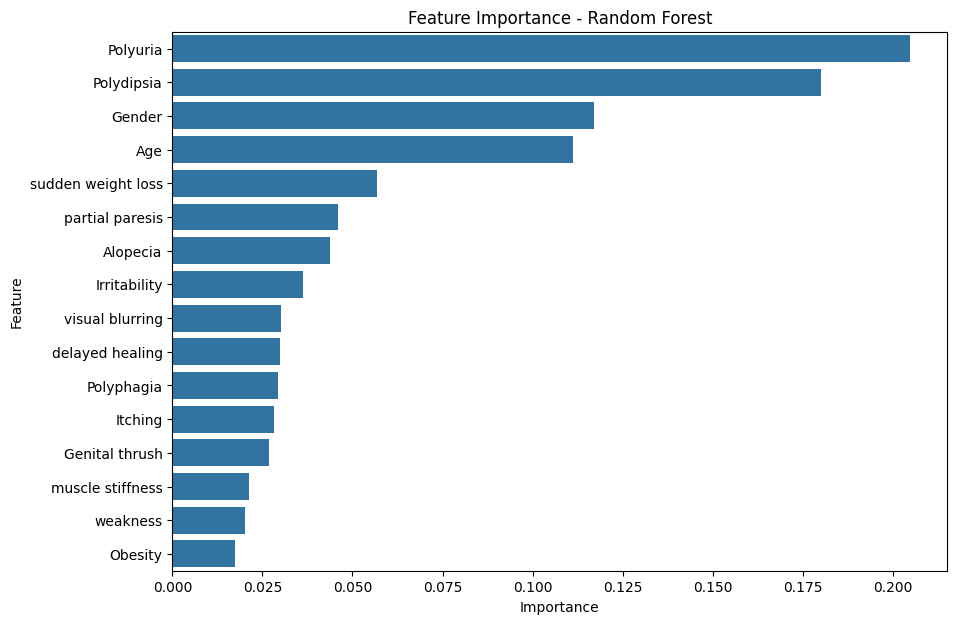

In [ ]:
plt.figure(figsize=(10, 7))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [ ]:
new_patient = pd.DataFrame({
    "Age": [45],
    "Gender": [1],
    "Polyuria": [1],
    "Polydipsia": [1],
    "sudden weight loss": [1],
    "weakness": [1],
    "Polyphagia": [1],
    "Genital thrush": [0],
    "visual blurring": [1],
    "Itching": [0],
    "Irritability": [1],
    "delayed healing": [1],
    "partial paresis": [0],
    "muscle stiffness": [1],
    "Alopecia": [0],
    "Obesity": [1]
})

print("New patient data:")
display(new_patient)

New patient data:


,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity
0,45,1,1,1,1,1,1,0,1,0,1,1,0,1,0,1


In [ ]:
rf_result = rf.predict(new_patient)

if rf_result[0] == 1:
    print("Random Forest Prediction: POSITIVE")
else:
    print("Random Forest Prediction: NEGATIVE")

Random Forest Prediction: POSITIVE


In [ ]:
new_patient_scaled = scaler.transform(new_patient)

knn_result = knn.predict(new_patient_scaled)

if knn_result[0] == 1:
    print("KNN Prediction: POSITIVE")
else:
    print("KNN Prediction: NEGATIVE")

KNN Prediction: POSITIVE


In [ ]:
new_patient_scaled = scaler.transform(new_patient)

predictions = {
    "KNN": knn.predict(new_patient_scaled)[0],
    "Naive Bayes": nb.predict(new_patient_scaled)[0],
    "SVM": svm.predict(new_patient_scaled)[0],
    "Decision Tree": dt.predict(new_patient)[0],
    "Random Forest": rf.predict(new_patient)[0]
}

for model, prediction in predictions.items():

    result = "POSITIVE" if prediction == 1 else "NEGATIVE"

    print(model, ":", result)

KNN : POSITIVE
Naive Bayes : POSITIVE
SVM : POSITIVE
Decision Tree : POSITIVE
Random Forest : POSITIVE


In [ ]:
positive_count = sum(predictions.values())
total_models = len(predictions)

if positive_count >= 3:
    final_prediction = "POSITIVE"
else:
    final_prediction = "NEGATIVE"

print("Final Prediction:", final_prediction)
print(
    "Positive predictions:",
    positive_count,
    "out of",
    total_models
)

Final Prediction: POSITIVE
Positive predictions: 5 out of 5


In [ ]:
import joblib

joblib.dump(rf, "diabetes_random_forest_model.pkl")
joblib.dump(scaler, "diabetes_scaler.pkl")

print("Random Forest model saved.")
print("Scaler saved.")

Random Forest model saved.
Scaler saved.
